In [3]:
#makes a file containing all the energy for each bond length

# h2plus_fci_pec.py
import psi4
import numpy as np
import csv

#choose basis (small to large):
#cc-pVDZ, cc-pVTZ, cc-pVQZ, cc-pV5Z,
#aug-cc-pVDZ, aug-cc-pVTZ, aug-cc-pVQZ, aug-cc-pV5Z"

basis = "aug-cc-pV5Z"

roots = 5                                        #number of potential energy curves to calculate, including ground state

r_min, r_max, n_points = 0.2, 5.0, 1000          #max and min bond length, number of points
csv_out = "h2plus_fci_pec.csv"                   #name csv output file
psi4_out = "h2plus_fci_scan.out"                 #name psi4 output file

psi4.set_output_file(psi4_out, False)            #(Names output file, overrides existing files)
psi4.set_memory("4 GB")                          #How much ram psi4 is allowed to use
psi4.set_num_threads(4)                          #number of threads to use

#set up psi4
psi4.core.clean_options()        #resets options
psi4.set_options({
    "basis": basis,              #set basis
    "reference": "rohf",         #Restricted Open-Shell Hartree-Fock, needed for open shell system, can also use uhf
    "guess": "sad",              #initial guess
    "scf_type": "pk",            #compute exact integrals
    "e_convergence": 1e-10,      #convergence limits
    "d_convergence": 1e-10,
    "maxiter": 200,              #max iterations
    "num_roots": roots,
})

#create an array of points
bond_lengths = np.linspace(r_min, r_max, n_points)

#run scan for each root at a set R
def run_h2plus_fci(R, roots, basis):        
    #create molecule
    mol = psi4.geometry(f"""
        1 2                               #charge, multiplicity
        H                                 #first hydrogen at (0,0,0)
        H 1 {R}                           #second hydrogen at distance R from hydrogen #1
        units angstrom                    #units of R in angstroms
        symmetry c1                       #turns off symmetry
        """)
    
    psi4.core.clean()                     #removes scratch files, clears data
    psi4.energy("fci", molecule=mol)      #calculate energy using Full Configuration Interaction for my mol
    vars_dict = psi4.core.variables()     #creates a dictionary with psi4 variables

    energies = []                         #create an empty list for energies

    #add each calculated root to the energies list
    for n in range(roots):
        energies.append(vars_dict[f"CI ROOT {n} TOTAL ENERGY"])

    #returns a list of the energies of each root at the n values
    return energies

#empty list for rows
rows = []

#run psi4 for each R
for R in bond_lengths:
    try:
        energies = run_h2plus_fci(R, roots, basis)   #runs function for R
        rows.append([R] + energies)                  #adds ([R], [energies]) to my list of rows
        #print(f"R = {R:.3f} done")                  #print when done
    except Exception as err:                         #If it fails
        print(f"R = {R:.3f} failed: {err}")          #print if it fails
        rows.append([R] + [np.nan] * roots)          #leave a gap for failure
    finally:
        psi4.core.clean()
        psi4.core.clean_options()

#write csv file
with open(csv_out, "w", newline="") as f:            #opens csv file, overwrite existing file, prevent blank lines
    w = csv.writer(f)                                #make csv writer
    headers = ["R_angstrom"]                         #list for headers, starting with R
    for i in range (roots):
        headers.append(f"E_root{i}")                 #Add a new header for each root
    writer.writerow(headers)                         #make row with header
    writer.writerows(rows)                           #add data to csv file

print("Done. Wrote h2plus_fci_pec.csv")  




  Memory set to   1.863 GiB by Python driver.
  Threads set to 4 by Python driver.
R = 0.200 done
R = 0.210 done
R = 0.219 done
R = 0.229 done
R = 0.238 done
R = 0.248 done
R = 0.258 done
R = 0.267 done
R = 0.277 done
R = 0.287 done
R = 0.296 done
R = 0.306 done
R = 0.315 done
R = 0.325 done
R = 0.335 done
R = 0.344 done
R = 0.354 done
R = 0.364 done
R = 0.373 done
R = 0.383 done
R = 0.392 done
R = 0.402 done
R = 0.412 done
R = 0.421 done
R = 0.431 done
R = 0.440 done
R = 0.450 done
R = 0.460 done
R = 0.469 done
R = 0.479 done
R = 0.489 done
R = 0.498 done
R = 0.508 done
R = 0.517 done
R = 0.527 done
R = 0.537 done
R = 0.546 done
R = 0.556 done
R = 0.566 done
R = 0.575 done
R = 0.585 done
R = 0.594 done
R = 0.604 done
R = 0.614 done
R = 0.623 done
R = 0.633 done
R = 0.642 done
R = 0.652 done
R = 0.662 done
R = 0.671 done
R = 0.681 done
R = 0.691 done
R = 0.700 done
R = 0.710 done
R = 0.719 done
R = 0.729 done
R = 0.739 done
R = 0.748 done
R = 0.758 done
R = 0.768 done
R = 0.777 done
R

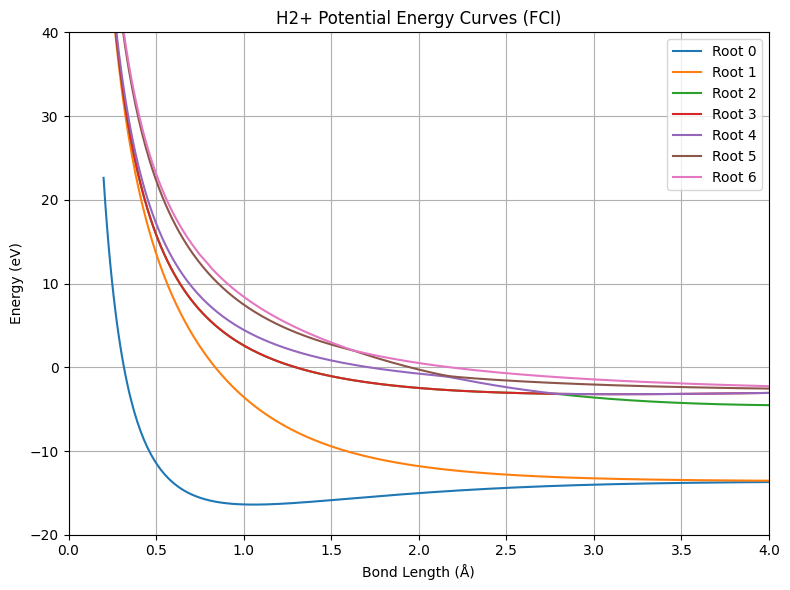

In [31]:
import csv
import numpy as np
import matplotlib.pyplot as plt

filename = "h2plus_fci_pec copy.csv"

 

R = []

with open(filename, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    n_roots = len(header) - 1
    energies = [[] for _ in range(n_roots)]
    
    for row in reader:
        R.append(float(row[0]))

        for i in range(n_roots):
            try:
                val = float(row[i+1])
            except:
                val = np.nan
            energies[i].append(val)

R = np.array(R)
energies = [np.array(e) for e in energies]

hartree_to_ev = 27.211396
for i in range(0,len(energies)):                                #shift each pec to 0
    energies[i] = energies[i] * hartree_to_ev                       #change units from hartree to ev

plt.figure(figsize=(8,6))
for i, e in enumerate(energies):
    plt.plot(R, e, label=f"Root {i}")
    
plt.ylim(-20, 40)
plt.xlim(0, 4)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (eV)")
plt.title("H2+ Potential Energy Curves (FCI)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
import psi4
import numpy as np
import csv

psi4.set_memory("2 GB")
psi4.set_num_threads(4)
psi4.core.set_output_file("h2_fci_scan.out", False)

roots = 10

def run_h2_fci(R, nroots = roots, basis="aug-cc-pVQZ"):
    psi4.core.clean()
    psi4.core.clean_options()

    mol = psi4.geometry(f"""
    0 1
    H
    H 1 {R}
    units angstrom
    """)

    psi4.set_options({
        "basis": basis,
        "reference": "rhf",
        "guess": "sad",
        "scf_type": "pk",
        "freeze_core": False,
        "num_roots": nroots
    })

    psi4.energy("fci", molecule=mol)
    vars_dict = psi4.core.variables()

    energies = []
    for n in range(nroots):
        key = f"CI ROOT {n} TOTAL ENERGY"
        energies.append(vars_dict[key])

    return energies

bond_lengths = np.linspace(0.2, 5.0, 200)

rows = []
for R in bond_lengths:
    try:
        energies = run_h2_fci(R, roots, basis="aug-cc-pVQZ")
        rows.append([R] + energies)
        print(f"R = {R:.3f} done")
    except Exception as err:
        print(f"R = {R:.3f} failed: {err}")
        rows.append([R] + [np.nan] * roots)
    finally:
        psi4.core.clean()
        psi4.core.clean_options()

with open("h2_fci_pec.csv", "w", newline="") as f:
    writer = csv.writer(f)
    write = ["R_angstrom"]
    for i in range (0, roots):
        write.append(f"E_root_{i}")
    writer.writerow(write)
    writer.writerows(rows)

print("Done. Wrote h2_fci_pec.csv")


  Memory set to   1.863 GiB by Python driver.
  Threads set to 4 by Python driver.
R = 0.200 done
R = 0.224 done
R = 0.248 done
R = 0.272 done
R = 0.296 done
R = 0.321 done
R = 0.345 done
R = 0.369 done
R = 0.393 done
R = 0.417 done
R = 0.441 done
R = 0.465 done
R = 0.489 done
R = 0.514 done
R = 0.538 done
R = 0.562 done
R = 0.586 done
R = 0.610 done
R = 0.634 done
R = 0.658 done
R = 0.682 done
R = 0.707 done
R = 0.731 done
R = 0.755 done
R = 0.779 done
R = 0.803 done
R = 0.827 done
R = 0.851 done
R = 0.875 done
R = 0.899 done
R = 0.924 done
R = 0.948 done
R = 0.972 done
R = 0.996 done
R = 1.020 done
R = 1.044 done
R = 1.068 done
R = 1.092 done
R = 1.117 done
R = 1.141 done
R = 1.165 done
R = 1.189 done
R = 1.213 done
R = 1.237 done
R = 1.261 done
R = 1.285 done
R = 1.310 done
R = 1.334 done
R = 1.358 done
R = 1.382 done
R = 1.406 done
R = 1.430 done
R = 1.454 done
R = 1.478 done
R = 1.503 done
R = 1.527 done
R = 1.551 done
R = 1.575 done
R = 1.599 done
R = 1.623 done
R = 1.647 done
R

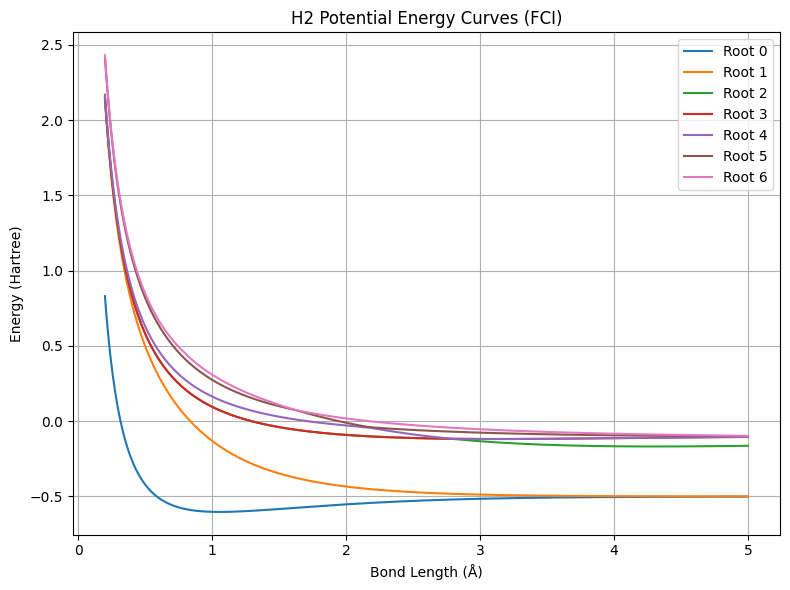

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import csv

filename = "h2_fci_pec.csv"

# Read data
R = []
energies = []

with open(filename, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    n_roots = len(header) - 1
    energies = [[] for _ in range(n_roots)]

    for row in reader:
        R.append(float(row[0]))

        for i in range(n_roots):
            try:
                val = float(row[i+1])
            except:
                val = np.nan
            energies[i].append(val)

R = np.array(R)
energies = [np.array(e) for e in energies]

# Plot
plt.figure(figsize=(8,6))

for i, e in enumerate(energies):
    plt.plot(R, e, label=f"Root {i}")

plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("H2 Potential Energy Curves (FCI)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
import psi4
import numpy as np
import csv

psi4.set_memory("2 GB")
psi4.set_num_threads(4)
psi4.core.set_output_file("h2_fci_spin_scan.out", False)

n_singlet_roots = 11
n_triplet_roots = 11
basis = "aug-cc-pVQZ"
bond_lengths = np.linspace(0.2, 5.0, 200)

def run_h2_fci(R, multiplicity, roots, basis=basis):
    psi4.core.clean()
    psi4.core.clean_options()

    mol = psi4.geometry(f"""
    0 {multiplicity}
    H
    H 1 {R}
    units angstrom
    """)

    reference = "rhf" if multiplicity == 1 else "rohf"

    psi4.set_options({
        "basis": basis,
        "reference": reference,
        "guess": "sad",
        "scf_type": "pk",
        "freeze_core": False,
        "num_roots": roots
    })

    psi4.energy("fci", molecule=mol)
    vars_dict = psi4.core.variables()

    energies = []
    for n in range(roots):
        key = f"CI ROOT {n} TOTAL ENERGY"
        energies.append(vars_dict[key])

    return energies

rows = []
for R in bond_lengths:
    singlet_energies = [np.nan] * n_singlet_roots
    triplet_energies = [np.nan] * n_triplet_roots

    try:
        singlet_energies = run_h2_fci(R, multiplicity=1, roots=n_singlet_roots, basis=basis)
        print(f"R = {R:.3f} singlet done")
    except Exception as err:
        print(f"R = {R:.3f} singlet failed: {err}")

    try:
        triplet_energies = run_h2_fci(R, multiplicity=3, roots=n_triplet_roots, basis=basis)
        print(f"R = {R:.3f} triplet done")
    except Exception as err:
        print(f"R = {R:.3f} triplet failed: {err}")

    row = [R] + singlet_energies + triplet_energies
    rows.append(row)

header = ["R_angstrom"]
header += [f"E_singlet_root_{i}" for i in range(n_singlet_roots)]
header += [f"E_triplet_root_{i}" for i in range(n_triplet_roots)]

with open("h2_fci_singlet_triplet.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print("Done. Wrote h2_fci_singlet_triplet.csv")


  Memory set to   1.863 GiB by Python driver.
  Threads set to 4 by Python driver.
R = 0.200 singlet done
R = 0.200 triplet done
R = 0.224 singlet done
R = 0.224 triplet done
R = 0.248 singlet done
R = 0.248 triplet done
R = 0.272 singlet done
R = 0.272 triplet done
R = 0.296 singlet done
R = 0.296 triplet done
R = 0.321 singlet done
R = 0.321 triplet done
R = 0.345 singlet done
R = 0.345 triplet done
R = 0.369 singlet done
R = 0.369 triplet done
R = 0.393 singlet done
R = 0.393 triplet done
R = 0.417 singlet done
R = 0.417 triplet done
R = 0.441 singlet done
R = 0.441 triplet done
R = 0.465 singlet done
R = 0.465 triplet done
R = 0.489 singlet done
R = 0.489 triplet done
R = 0.514 singlet done
R = 0.514 triplet done
R = 0.538 singlet done
R = 0.538 triplet done
R = 0.562 singlet done
R = 0.562 triplet done
R = 0.586 singlet done
R = 0.586 triplet done
R = 0.610 singlet done
R = 0.610 triplet done
R = 0.634 singlet done
R = 0.634 triplet done
R = 0.658 singlet done
R = 0.658 triplet d

12


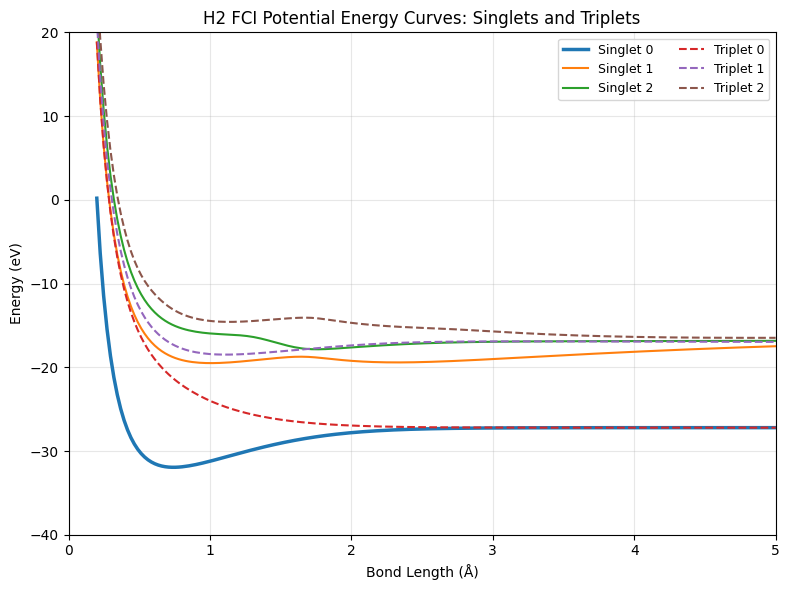

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import csv

filename = "h2_fci_singlet_triplet copy.csv"

R = []
singlets = []
triplets = []

with open(filename, "r") as f:
    reader = csv.reader(f)
    header = next(reader)

    ncols = len(header) - 1
    print(ncols)
    half = ncols // 2

    singlets = [[] for _ in range(3)]
    triplets = [[] for _ in range(3)]

    for row in reader:
        R.append(float(row[0]))

        for i in range(3):
            try:
                singlets[i].append(float(row[1 + i]))
            except:
                singlets[i].append(np.nan)

        for i in range(3):
            try:
                triplets[i].append(float(row[1 + half + i]))
            except:
                triplets[i].append(np.nan)

R = np.array(R)
singlets = [np.array(x) for x in singlets]
triplets = [np.array(x) for x in triplets]

hartree_to_ev = 27.211396
for i in range(0,len(singlets)):                                #shift each pec to 0
    singlets[i] = singlets[i] * hartree_to_ev 
for i in range(0,len(triplets)):                                #shift each pec to 0
    triplets[i] = triplets[i] * hartree_to_ev 
    
plt.figure(figsize=(8, 6))

for i,e in enumerate(singlets):
    if i == 0:
        plt.plot(R, e, linewidth=2.5, label=f"Singlet {i}")
    else:
        plt.plot(R, e, label=f"Singlet {i}")

for i, e in enumerate(triplets):
    plt.plot(R, e, linestyle="--", label=f"Triplet {i}")
plt.ylim(-40,20)
plt.xlim(0,5)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (eV)")
plt.title("H2 FCI Potential Energy Curves: Singlets and Triplets")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()